In [1]:
import os
import torch
from torch import nn, einsum
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
import torch.nn.functional as F
import math
from fairscale.nn.checkpoint.checkpoint_activations import checkpoint_wrapper

In [2]:
%load_ext autoreload

%autoreload

from Models.WeatherGFT import GFT
from utils.dataloader_ddp import load_data
# from utils.dataloader import load_data
from utils.losses import weighted_rmse, weighted_mae, calculate_metrics

In [3]:
from torch.cuda.amp import autocast, GradScaler

In [4]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:1


## dataloader

In [5]:
from Data.weatherbench_128 import WeatherBench128
from torch.utils.data import DataLoader

valid_data_2018 = WeatherBench128(start_time='2018-01-01 00:00:00', end_time='2018-12-25 00:00:00',
                                include_target=False, lead_time=1, interval=6, muti_target_steps=6)
valid_loader_2018 = DataLoader(valid_data_2004, batch_size=4, shuffle=False, num_workers=4)

KeyboardInterrupt: 

In [ ]:
model_original = GFT(hidden_dim=256,
            encoder_layers=[3, 3, 3],
            edcoder_heads=[3, 6, 6],
            encoder_scaling_factors=[0.5, 0.5, 1], # [128, 256] --> [64, 128] --> [32, 64] --> [32, 64], that is, patch size = 4 (128/32)
            encoder_dim_factors=[-1, 2, 2],

            body_layers=[4, 4, 4, 4, 4, 4], # A total of 4x6=24 HybridBlock, corresponding to 6 hours (24x15min) of time evolution
            body_heads=[8, 8, 8, 8, 8, 8],
            body_scaling_factors=[1, 1, 1, 1, 1, 1],
            body_dim_factors=[1, 1, 1, 1, 1, 1],

            decoder_layers=[3, 3, 3],
            decoder_heads=[6, 6, 3],
            decoder_scaling_factors=[1, 2, 1],
            decoder_dim_factors=[1, 0.5, 1],

            channels=69,
            head_dim=128,
            window_size=[4,8],
            relative_pos_embedding=False,
            out_kernel=[2,2],

            pde_block_depth=3, # 1 HybridBlock contains 3 PDE kernels, corresponding to 15 minutes (3x300s) of time evolution
            block_dt=300, # One PDE kernel corresponds to 300s of time evolution
            inverse_time=False).to(device)

In [13]:
if os.path.exists('checkpoints/gft.ckpt'):
    ckpt = torch.load('checkpoints/gft.ckpt', map_location=device)
    model.load_state_dict(ckpt, strict=True)
    print('[complete loading model]')

[complete loading model]


In [14]:
# Считаем количество параметров
total_params = sum(p.numel() for p in model.parameters())

print(f'Количество параметров в модели: {total_params}')

Количество параметров в модели: 470584357


In [15]:
# Извлекаем веса всех слоев
weights = []
for param in model.parameters():
    if param.requires_grad:  # Это означает, что параметр обновляется во время обучения
        weights.append(param.data.cpu().numpy())  # Переводим в numpy для удобства

# Объединяем все веса в один массив для построения гистограммы
all_weights = np.concatenate([w.flatten() for w in weights])

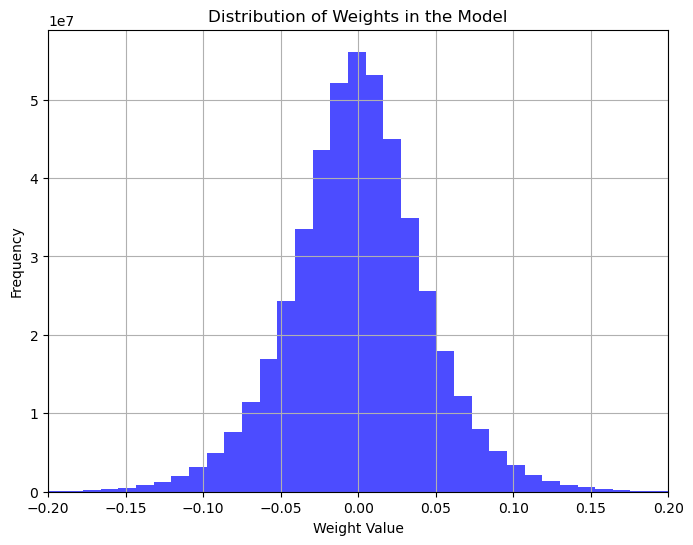

In [16]:
# Строим гистограмму
plt.figure(figsize=(8, 6))
plt.hist(all_weights, bins=1000, color='blue', alpha=0.7)
plt.title('Distribution of Weights in the Model')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.xlim(-0.2, 0.2)
plt.show()

## Вспомогательные функции

In [5]:
variable_list = [
        0, 1, 2, 4 ,
        6 ,7 ,8 ,9 ,10,11,12,13,14,15,16,17,18,
        19,20,21,22,23,24,25,26,27,28,29,30,31,
        45,46,47,48,49,50,51,52,53,54,55,56,57,
        58,59,60,61,62,63,64,65,66,67,68,69,70,
        71,72,73,74,75,76,77,78,79,80,81,82,83]

mean_std = np.load("/home/epbugaev/weather_bench/1.40625deg/mean_std.npy")
mean = torch.tensor(mean_std[0][variable_list]).reshape(1, 69, 1, 1).to(device).detach()
std = torch.tensor(mean_std[1][variable_list]).reshape(1, 69, 1, 1).to(device).detach()

In [12]:
from torch.nn.functional import l1_loss, mse_loss
import tqdm

def get_validation_accuracy(model, dataloader, complete_cycles=4):
    global mean, std
    
    key_ind = [0, 1, 6 + 7 - 2, 19 + 10 - 2] # t2m, u10, z500, t850
    
    with torch.no_grad():
        mistakes_list = torch.zeros((4, 24))
        mistakes_map = torch.zeros((4, 24, 128, 256))
        predictions_map = torch.zeros((4, 24, 128, 256))
        y_true_map = torch.zeros((4, 24, 128, 256))
        
        cnt_list = torch.zeros((4, 24))        
        for pred, y in tqdm.tqdm(dataloader):
            y = y.to(device) * std + mean    

            pred = pred.to(device)

            for i in range(complete_cycles):
                if len(pred.shape) == 5:
                    pred = pred[:, 5] # Leave only last_hour prediction and start from it
                
                pred = model(pred)

                for j in range(4):
                    for hour in range(6):                        
                        # print('loss i:', i, 'j:', j, ':', l1_loss((pred * std + mean)[:, hour, key_ind[j]], y[:, hour + i * 6, key_ind[j]]).cpu())
                        mistakes_list[j, hour + i * 6] += l1_loss((pred * std + mean)[:, hour, key_ind[j]], y[:, hour + i * 6, key_ind[j]]).cpu() #torch.sqrt(mse_loss((pred * std + mean)[:, hour, key_ind[j]], y[:, hour + i * 6, key_ind[j]])).cpu()
                        cnt_list[j, hour + i * 6] += 1  
                        
                    
                        predictions_map[j, hour + i * 6] += (pred * std + mean)[0, hour, key_ind[j]].cpu()
                        y_true_map[j, hour + i * 6] += y[0, hour + i * 6, key_ind[j]].cpu()
                        mistakes_map[j, hour + i * 6] += torch.abs((pred * std + mean)[0, hour, key_ind[j]] - y[0, hour + i * 6, key_ind[j]]).cpu()
                        
                        
    return mistakes_list / cnt_list, mistakes_map / cnt_list[:, :, None, None],\
           predictions_map / cnt_list[:, :, None, None], y_true_map / cnt_list[:, :, None, None]

In [7]:
def load_model(model, path, cut_names=True): 
    ckpt = torch.load(path, map_location=torch.device('cpu'))
    weights = {}
    
    if cut_names:
        for key in ckpt['state_dict']: 
            weights[key[6:]] = ckpt['state_dict'][key]
    else: 
        weights = ckpt['state_dict']

    model.load_state_dict(weights, strict=True)
    print('[complete loading model]')
    return model

## Инференс наших версий модели

In [12]:
from Data.weatherbench_128 import WeatherBench128
from torch.utils.data import DataLoader

valid_data_2004 = WeatherBench128(start_time='2004-01-01 00:00:00', end_time='2004-12-25 00:00:00',
                                include_target=False, lead_time=1, interval=47, muti_target_steps=24)
valid_loader_2004 = DataLoader(valid_data_2004, batch_size=1, shuffle=False, num_workers=4)

In [15]:
model_ours = GFT(hidden_dim=256,
            physics_part_coef=0.1,
            encoder_layers=[2, 2, 2],
            edcoder_heads=[2, 4, 4],
            encoder_scaling_factors=[0.5, 0.5, 1], # [128, 256] --> [64, 128] --> [32, 64] --> [32, 64], that is, patch size = 4 (128/32)
            encoder_dim_factors=[-1, 2, 2],

            body_layers=[4, 4, 4, 4, 4, 4], # A total of 4x6=24 HybridBlock, corresponding to 6 hours (24x15min) of time evolution
            body_heads=[6, 6, 6, 6, 6, 6],
            body_scaling_factors=[1, 1, 1, 1, 1, 1],
            body_dim_factors=[1, 1, 1, 1, 1, 1],

            decoder_layers=[2, 2, 2],
            decoder_heads=[4, 4, 2],
            decoder_scaling_factors=[1, 2, 1],
            decoder_dim_factors=[1, 0.5, 1],

            channels=69,
            head_dim=128,
            window_size=[4,8],
            relative_pos_embedding=False,
            out_kernel=[2,2],

            pde_block_depth=3, # 1 HybridBlock contains 3 PDE kernels, corresponding to 15 minutes (3x300s) of time evolution
            block_dt=300, # One PDE kernel corresponds to 300s of time evolution
            inverse_time=False).to(device)

model_ours.eval()
model_ours.out_layer = [0, 1, 2, 3, 4, 5]

In [16]:
ckpt = torch.load('/home/epbugaev/checkpoints/physics_imp_is_0dot1 fixed/2024-12-19-14:215isgc/epoch=15-val_loss=0.0670.ckpt', map_location=torch.device('cpu'))
weights = {}
for key in ckpt['state_dict']: 
    weights[key[6:]] = ckpt['state_dict'][key]

model_ours.load_state_dict(weights, strict=True)
print('[complete loading model]')

[complete loading model]


In [17]:
mistakes_coef_01, mistakes_map_01, pred_map_01, y_true_map_01  = get_validation_accuracy(model_ours, valid_loader_2004, complete_cycles=4)

100%|██████████| 184/184 [11:26<00:00,  3.73s/it]


In [18]:
dict_validation_coef_01 = {'t2m': mistakes_coef_01[0], 'u10': mistakes_coef_01[1], 'z500': mistakes_coef_01[2], 't850': mistakes_coef_01[3]}
dict_validation_coef_01_maps = {'mistakes': mistakes_map_01, 'pred': pred_map_01, 'real': y_true_map_01}

torch.save(dict_validation_coef_01, 'checkpoints/physical_01_validation.results')
torch.save(dict_validation_coef_01_maps, 'checkpoints/physical_01_validation_maps.results')

In [29]:
mistakes_coef_01_2018, mistakes_map_01_2018, pred_map_01_2018, y_true_map_01_2018  = get_validation_accuracy(model_ours, valid_loader_2018, complete_cycles=4)

100%|██████████| 183/183 [13:00<00:00,  4.26s/it]


In [30]:
dict_validation_coef_01_2018 = {'t2m': mistakes_coef_01_2018[0], 'u10': mistakes_coef_01_2018[1], 'z500': mistakes_coef_01_2018[2], 't850': mistakes_coef_01_2018[3]}
dict_validation_coef_01_maps_2018 = {'mistakes': mistakes_map_01_2018, 'pred': pred_map_01_2018, 'real': y_true_map_01_2018}

torch.save(dict_validation_coef_01_2018, 'checkpoints/physical_01_validation_2018.results')
torch.save(dict_validation_coef_01_maps_2018, 'checkpoints/physical_01_validation_maps_2018.results')

[]

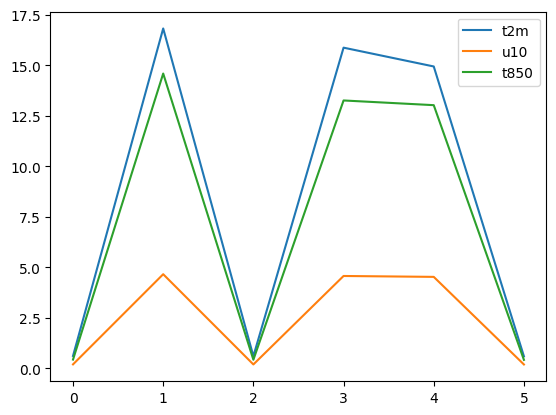

In [30]:
import matplotlib.pyplot as plt

plot.title('Predictions in single model run')
plt.xlabel('Hours')
plt.ylabel('MAE')
plt.plot(range(6), mistakes_coef_01[0, :6], label='t2m')
plt.plot(range(6), mistakes_coef_01[1, :6], label='u10')
#plt.plot(range(6), mistakes_coef_01[2, :6], label='z500')
plt.plot(range(6), mistakes_coef_01[3, :6], label='t850')

plt.legend()
plt.plot()

In [38]:
print(mistakes_coef_01[0])

tensor([ 0.6138, 16.8176,  0.6007, 15.8682, 14.9377,  0.5936,  0.6386, 16.8169,
         0.6273, 15.8592, 14.9264,  0.6227,  0.6692, 16.8174,  0.6596, 15.8507,
        14.9188,  0.6570,  0.7045, 16.8193,  0.6963, 15.8430, 14.9136,  0.6951])


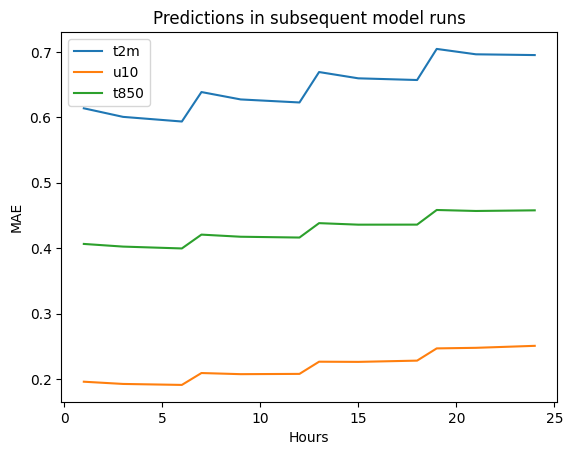

In [40]:
import matplotlib.pyplot as plt

plt.title('Predictions in subsequent model runs')
plt.xlabel('Hours')
plt.ylabel('MAE')

ids = np.array([0, 2, 5, 6, 8, 11, 12, 14, 17, 18, 20, 23])

plt.plot(ids + 1, mistakes_coef_01[0, ids], label='t2m')
plt.plot(ids + 1, mistakes_coef_01[1, ids], label='u10')
#plt.plot(range(6), mistakes_coef_01[2, :6], label='z500')
plt.plot(ids + 1, mistakes_coef_01[3, ids], label='t850')

plt.legend()
plt.show()

## Инференс оригинальной модели

In [8]:
from Data.weatherbench_128 import WeatherBench128
from torch.utils.data import DataLoader

valid_data_2004 = WeatherBench128(start_time='2004-01-01 00:00:00', end_time='2004-12-25 00:00:00',
                                include_target=False, lead_time=1, interval=47, muti_target_steps=24)
valid_loader_2004 = DataLoader(valid_data_2004, batch_size=1, shuffle=False, num_workers=4)

In [26]:
from Data.weatherbench_128 import WeatherBench128
from torch.utils.data import DataLoader

valid_data_2018 = WeatherBench128(start_time='2018-01-01 00:00:00', end_time='2018-12-25 00:00:00',
                                include_target=False, lead_time=1, interval=47, muti_target_steps=24)
valid_loader_2018 = DataLoader(valid_data_2018, batch_size=1, shuffle=False, num_workers=4)

In [9]:
model_original = GFT(hidden_dim=256,
            physics_part_coef=0.1,
            encoder_layers=[2, 2, 2],
            edcoder_heads=[3, 6, 6],
            encoder_scaling_factors=[0.5, 0.5, 1], # [128, 256] --> [64, 128] --> [32, 64] --> [32, 64], that is, patch size = 4 (128/32)
            encoder_dim_factors=[-1, 2, 2],

            body_layers=[4, 4, 4, 4, 4, 4], # A total of 4x6=24 HybridBlock, corresponding to 6 hours (24x15min) of time evolution
            body_heads=[8, 8, 8, 8, 8, 8],
            body_scaling_factors=[1, 1, 1, 1, 1, 1],
            body_dim_factors=[1, 1, 1, 1, 1, 1],

            decoder_layers=[2, 2, 2],
            decoder_heads=[6, 6, 3],
            decoder_scaling_factors=[1, 2, 1],
            decoder_dim_factors=[1, 0.5, 1],

            channels=69,
            head_dim=128,
            window_size=[4,8],
            relative_pos_embedding=False,
            out_kernel=[2,2],

            pde_block_depth=3, # 1 HybridBlock contains 3 PDE kernels, corresponding to 15 minutes (3x300s) of time evolution
            block_dt=300, # One PDE kernel corresponds to 300s of time evolution
            inverse_time=False).to(device)

model_original.eval()
model_original.out_layer = [0, 1, 2, 3, 4, 5]

In [10]:
ckpt = torch.load('/home/epbugaev/WeatherPredictions/checkpoints/gft.ckpt', map_location=torch.device('cpu'))
weights = {}
#for key in ckpt['state_dict']: 
#    weights[key[6:]] = ckpt['state_dict'][key]
weights = ckpt

model_original.load_state_dict(weights, strict=True)
print('[complete loading model]')

[complete loading model]


In [13]:
mistakes_coef_original_mae_2004, mistakes_map_original_2004, pred_map_original_2004, y_true_map_original_2004 = get_validation_accuracy(model_original, valid_loader_2004, complete_cycles=4)

100%|██████████| 184/184 [11:46<00:00,  3.84s/it]


In [19]:
dict_validation_original = {'t2m': mistakes_coef_original_mae_2004[0], 'u10': mistakes_coef_original_mae_2004[1], 'z500': mistakes_coef_original_mae_2004[2], 't850': mistakes_coef_original_mae_2004[3]}
torch.save(dict_validation_original, 'checkpoints/original_mae_2004_double_check.results')

dict_validation_original_maps = {'mistakes': mistakes_map_original_2004, 'pred': pred_map_original_2004, 'real': y_true_map_original_2004}
torch.save(dict_validation_original_maps, 'checkpoints/original_maps.results')

In [31]:
mistakes_coef_original_mae_2018, mistakes_map_original_2018, pred_map_original_2018, y_true_map_original_2018 = get_validation_accuracy(model_original, valid_loader_2018, complete_cycles=4)

100%|██████████| 183/183 [13:19<00:00,  4.37s/it]


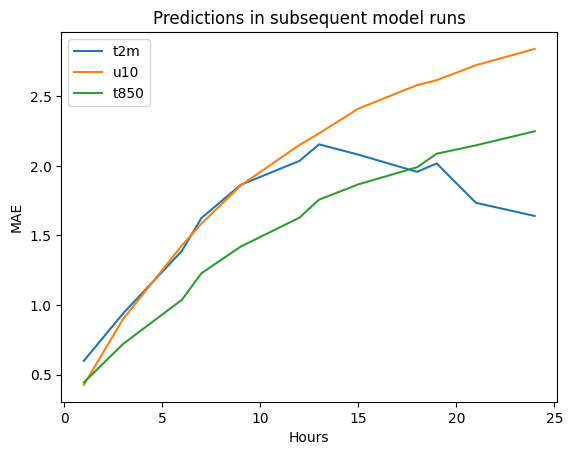

In [29]:
import matplotlib.pyplot as plt

plt.title('Predictions in subsequent model runs')
plt.xlabel('Hours')
plt.ylabel('MAE')

ids = np.array([0, 2, 5, 6, 8, 11, 12, 14, 17, 18, 20, 23])

plt.plot(ids + 1, mistakes_coef_original[0, ids], label='t2m')
plt.plot(ids + 1, mistakes_coef_original[1, ids], label='u10')
#plt.plot(range(6), mistakes_coef_01[2, :6], label='z500')
plt.plot(ids + 1, mistakes_coef_original[3, ids], label='t850')

plt.legend()
plt.show()

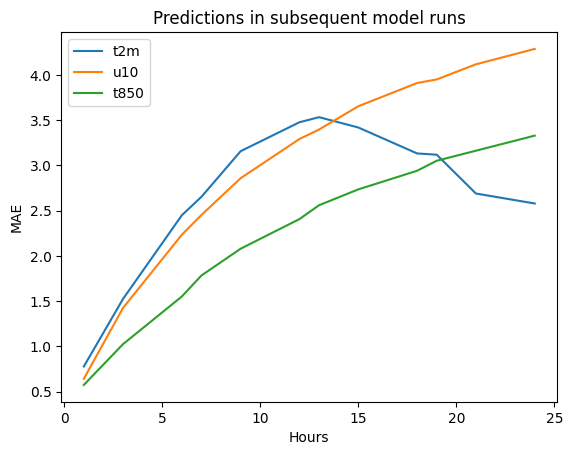

In [30]:
import matplotlib.pyplot as plt

plt.title('Predictions in subsequent model runs')
plt.xlabel('Hours')
plt.ylabel('MAE')

ids = np.array([0, 2, 5, 6, 8, 11, 12, 14, 17, 18, 20, 23])

plt.plot(ids + 1, mistakes_coef_original_rmse[0, ids], label='t2m')
plt.plot(ids + 1, mistakes_coef_original_rmse[1, ids], label='u10')
#plt.plot(range(6), mistakes_coef_01[2, :6], label='z500')
plt.plot(ids + 1, mistakes_coef_original_rmse[3, ids], label='t850')

plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.title('Predictions in subsequent model runs')
plt.xlabel('Hours')
plt.ylabel('MAE')

ids = np.array([0, 2, 5, 6, 8, 11, 12, 14, 17, 18, 20, 23])

plt.plot(ids + 1, mistakes_coef_original_rmse[0, ids], label='t2m')
plt.plot(ids + 1, mistakes_coef_original_rmse[1, ids], label='u10')
#plt.plot(range(6), mistakes_coef_01[2, :6], label='z500')
plt.plot(ids + 1, mistakes_coef_original_rmse[3, ids], label='t850')

plt.legend()
plt.show()

## Оригинальная модель: предсказания через 1, 3, 6 часов

In [22]:
validation_original_maps = torch.load('checkpoints/original_maps.results', map_location='cpu')

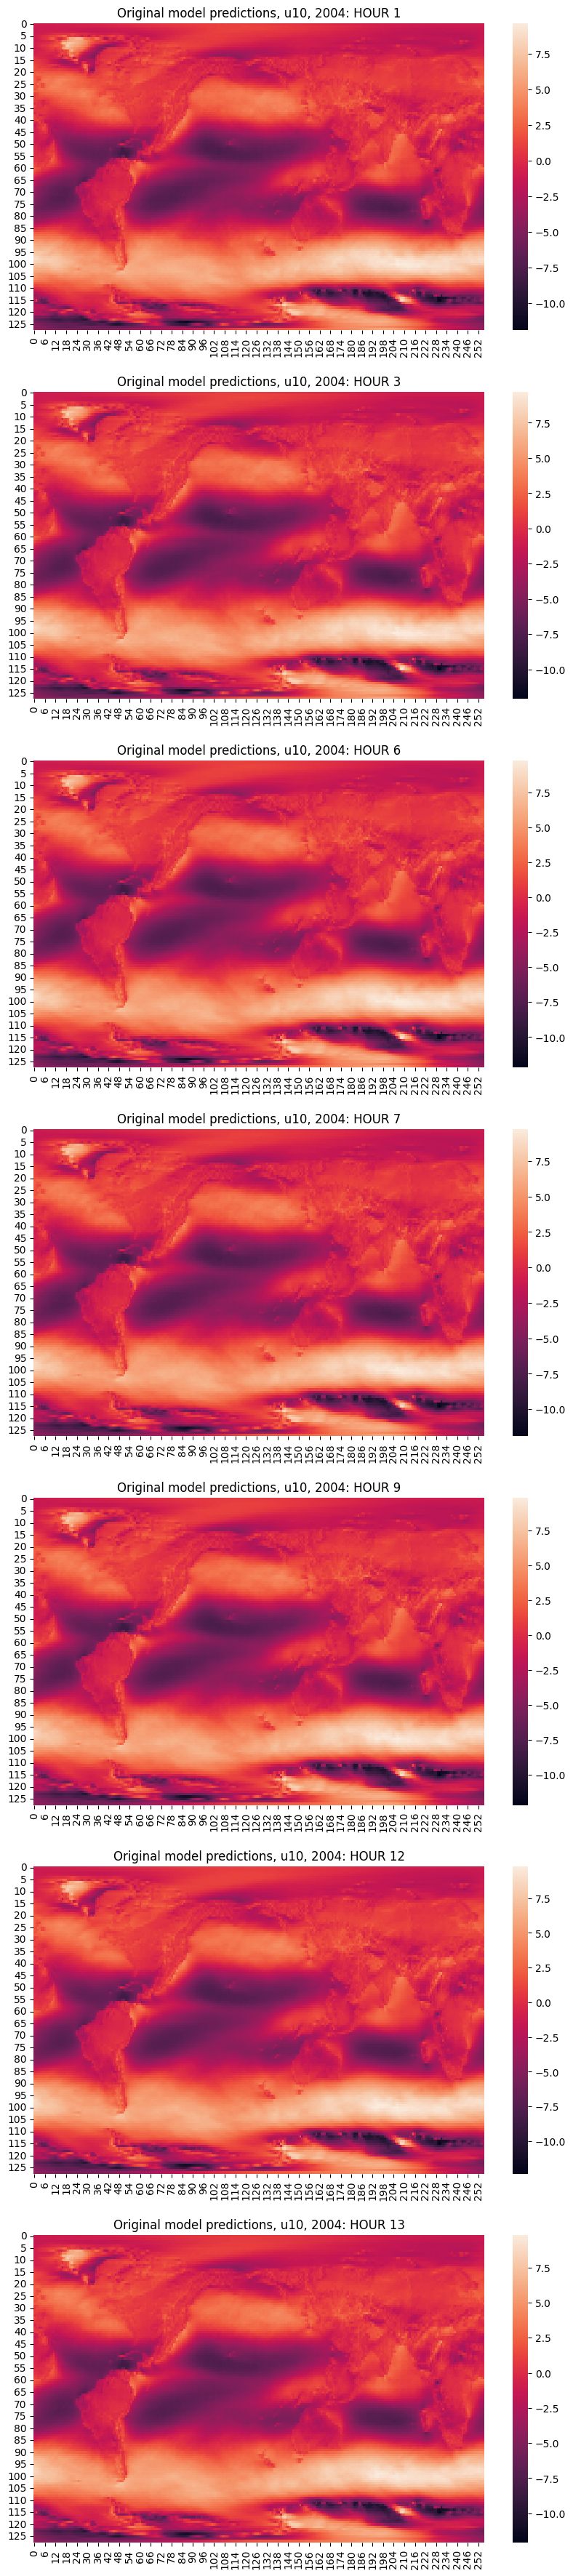

In [34]:
import seaborn as sns

fig, ax = plt.subplots(7, 1, figsize=(10, 45))

for id, hour in enumerate([0, 2, 5, 6, 8, 11, 12]): 
    sns.heatmap(torch.flip(validation_original_maps['pred'][1, hour], dims=(0, 1)), ax=ax[id])
    ax[id].set_title('Original model predictions, u10, 2004: HOUR ' + str(hour + 1))

plt.show()

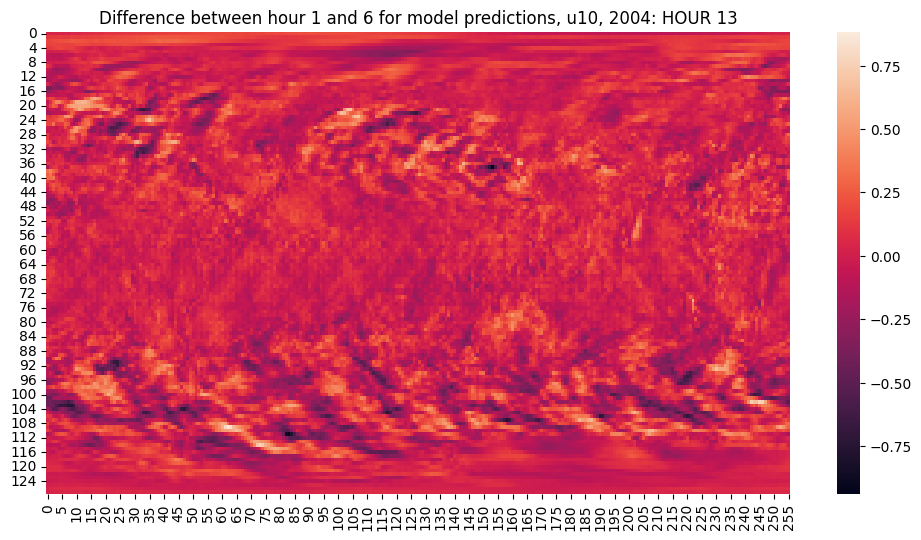

In [40]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.heatmap(torch.flip(validation_original_maps['pred'][1, 0] - validation_original_maps['pred'][1, 6], dims=(0, 1)), ax=ax)
ax.set_title('Difference between hour 1 and 6 for model predictions, u10, 2004: HOUR ' + str(hour + 1))

plt.show()

In [41]:
print('Average difference:', torch.mean(validation_original_maps['pred'][1, 0] - validation_original_maps['pred'][1, 6]))

Average difference: tensor(0.0075)


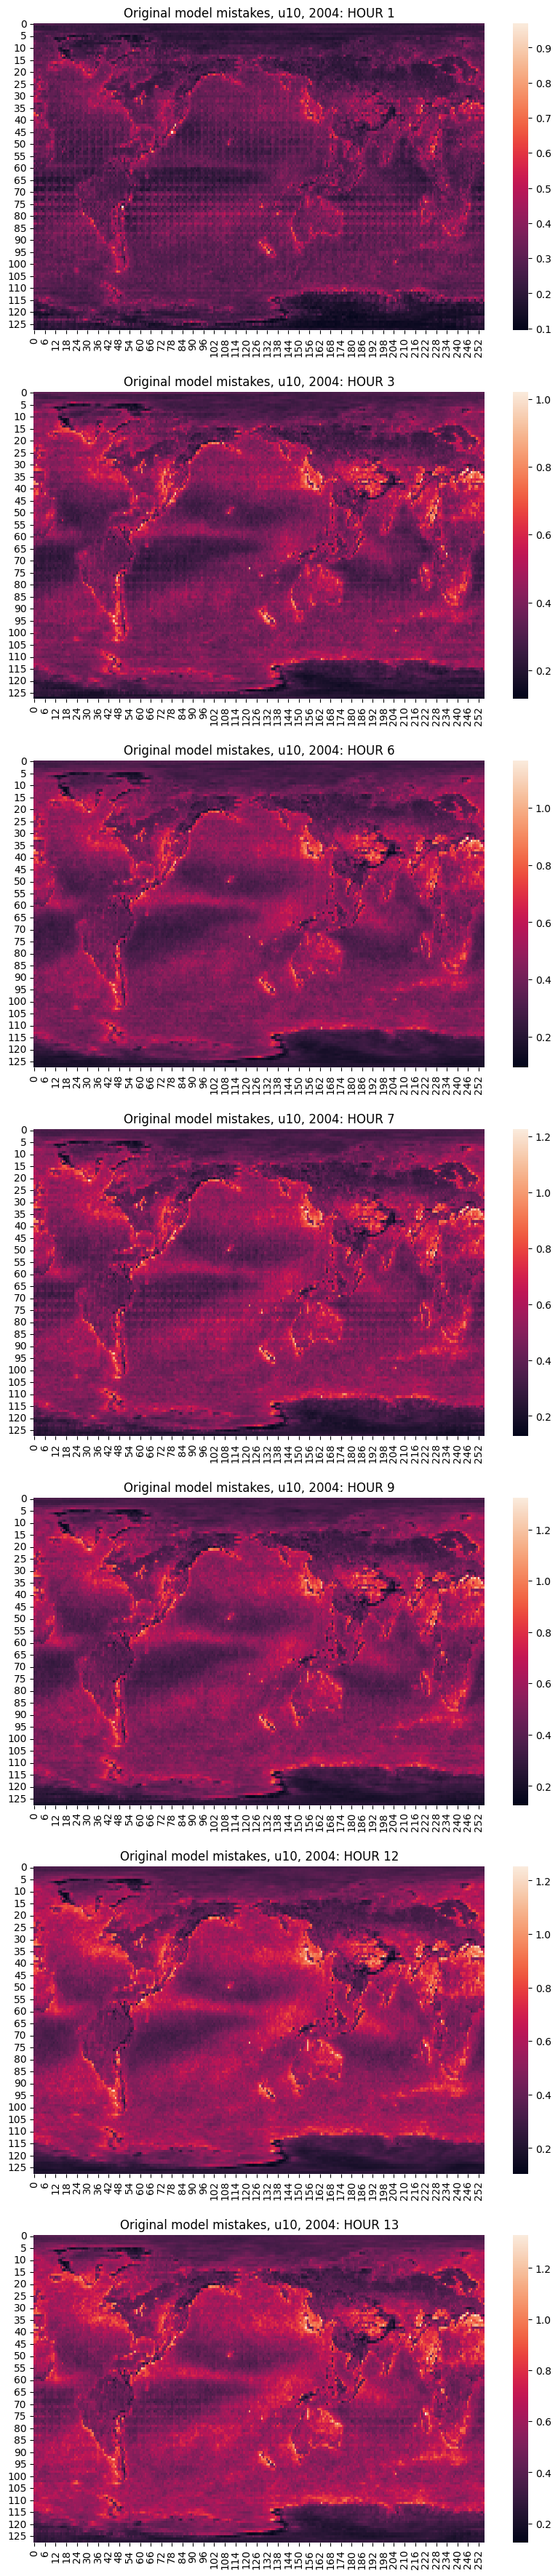

In [42]:
import seaborn as sns

fig, ax = plt.subplots(7, 1, figsize=(10, 45))

for id, hour in enumerate([0, 2, 5, 6, 8, 11, 12]): 
    sns.heatmap(torch.flip(validation_original_maps['mistakes'][1, hour], dims=(0, 1)), ax=ax[id])
    ax[id].set_title('Original model mistakes, u10, 2004: HOUR ' + str(hour + 1))

plt.show()

In [43]:
print('Average mistake hour 1:', torch.mean(validation_original_maps['mistakes'][1, 0]))
print('Average mistake hour 6:', torch.mean(validation_original_maps['mistakes'][1, 5]))

Average mistake hour 1: tensor(0.3072)
Average mistake hour 6: tensor(0.4165)


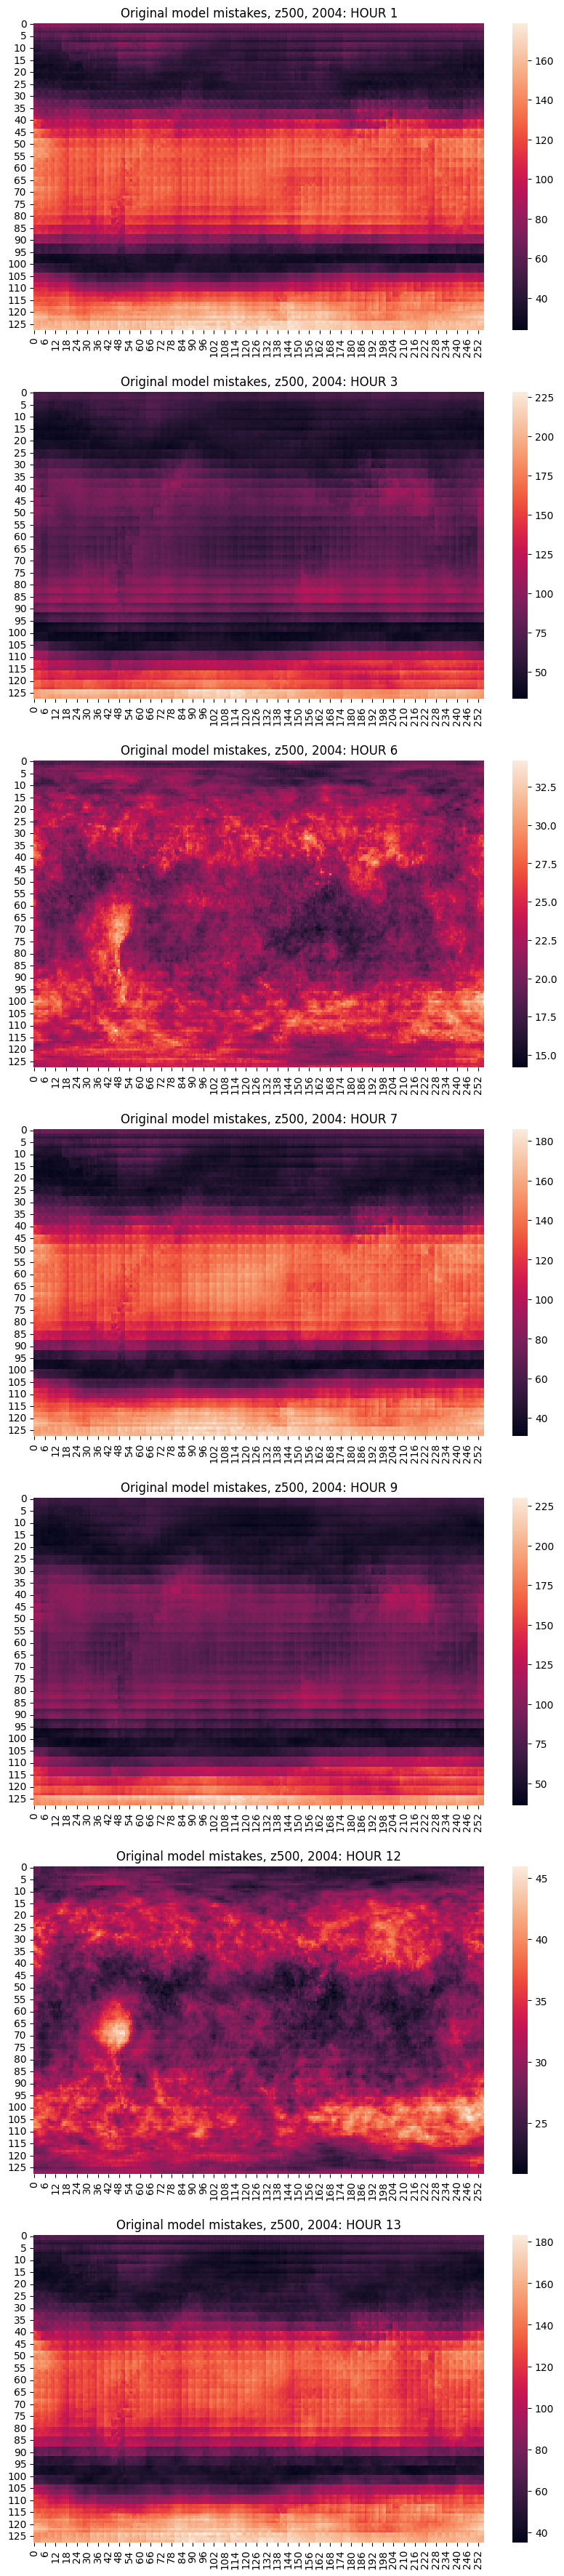

In [44]:
import seaborn as sns

fig, ax = plt.subplots(7, 1, figsize=(10, 45))

for id, hour in enumerate([0, 2, 5, 6, 8, 11, 12]): 
    sns.heatmap(torch.flip(validation_original_maps['mistakes'][2, hour], dims=(0, 1)), ax=ax[id])
    ax[id].set_title('Original model mistakes, z500, 2004: HOUR ' + str(hour + 1))

plt.show()